<a href="https://colab.research.google.com/github/Ono-se/O-List-E-Commerce-Analysis/blob/main/O_List_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Olist E-Commerce Data Analysis Using SQL

## Overview

This project analyzes the Olist Brazilian E-Commerce Public Dataset using SQL.

The analysis focuses on understanding e-commerce performance through customer orders, payments, products, sellers, and delivery information.

DuckDB is used to perform SQL analysis directly in Google Colab, with the dataset stored in Google Drive.

## Objectives

- Explore the structure of the Olist dataset
- Analyze order and customer activity
- Examine sales and payment patterns
- Investigate delivery performance
- Analyze product and seller performance
- Extract business insights using SQL

## Tools and Technologies

- SQL
- DuckDB
- Google Colab
- Python
- Pandas

## Dataset

The Olist Brazilian E-Commerce Public Dataset contains information about approximately 100,000 orders made through the Olist marketplace in Brazil.

The dataset contains multiple related tables covering:

- Orders
- Customers
- Order items
- Products
- Sellers
- Payments
- Reviews
- Geolocation
- Product categories

## 1. Environment Setup

The dataset is stored in Google Drive and accessed through Google Colab.

DuckDB is used as the SQL engine, allowing the CSV files to be queried using SQL without requiring a separate database server.

In [1]:
!pip install duckdb

In [2]:
# Import libraries
import os
import glob
import duckdb
import pandas as pd

In [ ]:
# Connect Google Drive
from google.colab import drive
drive.mount('/content/drive')

In [3]:
# Path to the Olist dataset

folder = "/content/drive/MyDrive/Dataset/Olist_Brazilian_E_Commerce_Public_Dataset"

os.listdir(folder)

['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

In [4]:
# Create a DuckDB connection
con = duckdb.connect()

## 2. Loading the Dataset

Each CSV file represents a separate table in the Olist relational dataset.

The files are loaded into DuckDB so that they can be queried using SQL.

In [5]:
# Find all CSV files in the dataset folder
csv_files = glob.glob(folder + "/*.csv")

In [6]:
# Load each CSV file as a DuckDB table
for file in csv_files:
    table_name = os.path.basename(file).replace(".csv", "")

    con.execute(f"""
        CREATE OR REPLACE TABLE "{table_name}" AS
        SELECT *
        FROM read_csv_auto('{file}')
    """)

print("All tables loaded successfully.")

All tables loaded successfully.


## 3. Exploring the Database Structure

Before performing analysis, it is important to understand the tables available in the database.

This helps identify relationships between customers, orders, products, sellers, and payments.

In [7]:
# Display all available tables
con.execute("SHOW TABLES").df()

,name
0,olist_customers_dataset
1,olist_geolocation_dataset
2,olist_order_items_dataset
3,olist_order_payments_dataset
4,olist_order_reviews_dataset
5,olist_orders_dataset
6,olist_products_dataset
7,olist_sellers_dataset
8,product_category_name_translation


## 4. Exploring Orders

The orders table contains information about when orders were placed, approved, delivered to the carrier, delivered to customers, and estimated for delivery.

The first step is to inspect a sample of the data.

In [8]:
# Display the first 10 orders
con.execute("""
SELECT *
FROM olist_orders_dataset
LIMIT 10
""").df()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23


### Total Number of Orders

How many orders are contained in the dataset?

In [9]:
# Count the total number of orders
con.execute("""
    SELECT COUNT(*) AS total_orders
    FROM olist_orders_dataset
""").df()

,total_orders
0,99441


### Order Status Distribution

Understanding the distribution of order statuses provides an overview of the different outcomes of orders in the marketplace.

In [10]:
# Count orders by their current status
con.execute("""
    SELECT
        order_status,
        COUNT(*) AS order_count
    FROM olist_orders_dataset
    GROUP BY order_status
    ORDER BY order_count DESC
""").df()

,order_status,order_count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


## 5. Order Volume Over Time

Analyzing order volume over time can reveal changes in customer activity and help identify periods of higher or lower demand.

The purchase timestamp is extracted into monthly periods to understand how order volume changes over time.

In [11]:
# Count orders by purchase month
con.execute("""
    SELECT
        DATE_TRUNC('month', order_purchase_timestamp) AS purchase_month,
        COUNT(*) AS order_count
    FROM olist_orders_dataset
    GROUP BY purchase_month
    ORDER BY purchase_month
""").df()

,purchase_month,order_count
0,2016-09-01,4
1,2016-10-01,324
2,2016-12-01,1
3,2017-01-01,800
4,2017-02-01,1780
5,2017-03-01,2682
6,2017-04-01,2404
7,2017-05-01,3700
8,2017-06-01,3245
9,2017-07-01,4026


### Customer Order Activity

The customers and orders tables are linked through `customer_id`.

Joining these tables allows us to examine how many orders customers placed and where those customers are located.

In [12]:
# Display the first 10 customers
con.execute("""
SELECT *
FROM olist_customers_dataset
LIMIT 10
""").df()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,09790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,01151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,08775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,04534,sao paulo,SP
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG


In [13]:
# Join customers with orders
con.execute("""
    SELECT
        c.customer_state,
        COUNT(o.order_id) AS total_orders
    FROM olist_customers_dataset AS c
    JOIN olist_orders_dataset AS o
        ON c.customer_id = o.customer_id
    GROUP BY c.customer_state
    ORDER BY total_orders DESC
""").df()

,customer_state,total_orders
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


### Geographic Distribution of Orders

The customer state provides a simple way to examine the geographic distribution of marketplace activity.

This analysis identifies the states with the highest number of orders.

In [14]:
# Identify the states with the highest number of orders
con.execute("""
    SELECT
        c.customer_state,
        COUNT(o.order_id) AS total_orders
    FROM olist_customers_dataset AS c
    JOIN olist_orders_dataset AS o
        ON c.customer_id = o.customer_id
    GROUP BY c.customer_state
    ORDER BY total_orders DESC
    LIMIT 10
""").df()

,customer_state,total_orders
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


### Customer Ordering Frequency

To understand customer activity, we can compare the total number of orders with the number of unique customers.

This provides an overall measure of ordering frequency within the marketplace.

In [15]:
# Calculate total orders, unique customers, and average orders per customer
con.execute("""
    SELECT
        COUNT(o.order_id) AS total_orders,
        COUNT(DISTINCT c.customer_id) AS unique_customers,
        ROUND(
            COUNT(o.order_id) * 1.0 / COUNT(DISTINCT c.customer_id),
            2
        ) AS avg_orders_per_customer
    FROM olist_customers_dataset AS c
    JOIN olist_orders_dataset AS o
        ON c.customer_id = o.customer_id
""").df()

,total_orders,unique_customers,avg_orders_per_customer
0,99441,99441,1.0



## 6. Analyzing Order Items

The `olist_order_items_dataset` table contains information about the products included in each order, including product price and freight value.

This table allows us to move beyond simply counting orders and begin analyzing transaction value.

In [16]:
# Inspect a sample of order items
con.execute("""
    SELECT *
    FROM olist_order_items_dataset
    LIMIT 10
""").df()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:31,19.90,11.85
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:56,53.99,11.40


### Total Product Revenue

The `price` column represents the price of each product included in an order.

Calculating the sum of product prices provides an estimate of the total product revenue represented in the dataset.

In [17]:
# Calculate total product revenue
con.execute("""
    SELECT
        ROUND(SUM(price), 2) AS total_product_revenue
    FROM olist_order_items_dataset
""").df()

,total_product_revenue
0,13591643.7


### Monthly Revenue

Analyzing revenue over time helps identify periods of higher and lower sales activity.

The order items table is joined with the orders table so that product revenue can be grouped according to the order purchase date.

In [18]:
# Calculate monthly product revenue
con.execute("""
    SELECT
        DATE_TRUNC('month', o.order_purchase_timestamp) AS purchase_month,
        ROUND(SUM(oi.price), 2) AS revenue
    FROM olist_order_items_dataset AS oi
    JOIN olist_orders_dataset AS o
        ON oi.order_id = o.order_id
    GROUP BY purchase_month
    ORDER BY purchase_month
""").df()

,purchase_month,revenue
0,2016-09-01,267.36
1,2016-10-01,49507.66
2,2016-12-01,10.90
3,2017-01-01,120312.87
4,2017-02-01,247303.02
5,2017-03-01,374344.30
6,2017-04-01,359927.23
7,2017-05-01,506071.14
8,2017-06-01,433038.60
9,2017-07-01,498031.48


### Revenue by Product Category

The products table contains product category information.

By joining order items with products, we can examine which product categories generated the most product revenue.

In [19]:
# Display the first 10 products
con.execute("""
SELECT *
FROM olist_products_dataset
LIMIT 10
""").df()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40,287,1,225,16,10,14
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44,276,1,1000,30,18,20
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46,250,1,154,18,9,15
3,cef67bcfe19066a932b7673e239eb23d,bebes,27,261,1,371,26,4,26
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37,402,4,625,20,17,13
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,60,745,1,200,38,5,11
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,56,1272,4,18350,70,24,44
7,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,56,184,2,900,40,8,40
8,37cc742be07708b53a98702e77a21a02,eletrodomesticos,57,163,1,400,27,13,17
9,8c92109888e8cdf9d66dc7e463025574,brinquedos,36,1156,1,600,17,10,12


In [20]:
# Calculate revenue by product category
con.execute("""
    SELECT
        p.product_category_name,
        ROUND(SUM(oi.price), 2) AS revenue
    FROM olist_order_items_dataset AS oi
    JOIN olist_products_dataset AS p
        ON oi.product_id = p.product_id
    GROUP BY p.product_category_name
    ORDER BY revenue DESC
    LIMIT 15
""").df()

,product_category_name,revenue
0,beleza_saude,1258681.34
1,relogios_presentes,1205005.68
2,cama_mesa_banho,1036988.68
3,esporte_lazer,988048.97
4,informatica_acessorios,911954.32
5,moveis_decoracao,729762.49
6,cool_stuff,635290.85
7,utilidades_domesticas,632248.66
8,automotivo,592720.11
9,ferramentas_jardim,485256.46


### Average Order Value

Average Order Value (AOV) measures the average amount spent on products per order.

It is calculated by dividing total product revenue by the number of unique orders containing products.

In [21]:
# Calculate Average Order Value (AOV)
con.execute("""
    SELECT
        ROUND(SUM(price), 2) AS total_revenue,
        COUNT(DISTINCT order_id) AS total_orders,
        ROUND(
            SUM(price) / COUNT(DISTINCT order_id),
            2
        ) AS average_order_value
    FROM olist_order_items_dataset
""").df()

,total_revenue,total_orders,average_order_value
0,13591643.7,98666,137.75


## 7. Freight and Shipping Cost Analysis

Shipping costs are an important component of e-commerce transactions.

The `freight_value` column in the order items table represents the freight charge associated with each item.

This section examines total freight costs and compares shipping costs with product prices.

In [22]:
# Calculate the total freight value
con.execute("""
    SELECT
        ROUND(SUM(freight_value), 2) AS total_freight
    FROM olist_order_items_dataset
""").df()

,total_freight
0,2251909.54


### Average Freight Cost

Calculating the average freight cost provides an overview of the typical shipping charge associated with an individual order item.

In [23]:
# Calculate the average freight cost per item
con.execute("""
    SELECT
        ROUND(AVG(freight_value), 2) AS avg_freight_cost
    FROM olist_order_items_dataset
""").df()

,avg_freight_cost
0,19.99


### Freight-to-Price Ratio

The freight-to-price ratio measures shipping cost relative to the product price.

A higher ratio indicates that shipping represents a larger proportion of the item's purchase price.

In [24]:
# Calculate the average freight-to-price ratio
con.execute("""
    SELECT
        ROUND(
            AVG(freight_value / NULLIF(price, 0)) * 100,
            2
        ) AS avg_freight_percentage
    FROM olist_order_items_dataset
""").df()

,avg_freight_percentage
0,32.09


### Freight Cost by Product Category

Different product categories may have substantially different shipping costs due to differences in product size, weight, or other logistics factors.

This analysis identifies categories with the highest average freight costs.

In [25]:
# Calculate average freight cost by product category
con.execute("""
    SELECT
        p.product_category_name,
        ROUND(AVG(oi.freight_value), 2) AS avg_freight,
        COUNT(*) AS items_sold
    FROM olist_order_items_dataset AS oi
    JOIN olist_products_dataset AS p
        ON oi.product_id = p.product_id
    GROUP BY p.product_category_name
    HAVING COUNT(*) >= 100
    ORDER BY avg_freight DESC
    LIMIT 15
""").df()

,product_category_name,avg_freight,items_sold
0,pcs,48.45,203
1,eletrodomesticos_2,44.54,238
2,moveis_cozinha_area_de_servico_jantar_e_jardim,42.70,281
3,moveis_quarto,42.50,109
4,moveis_escritorio,40.55,1691
5,moveis_sala,35.72,503
6,sinalizacao_e_seguranca,32.70,199
7,industria_comercio_e_negocios,29.42,268
8,malas_acessorios,27.88,1092
9,agro_industria_e_comercio,27.56,212


## 8. Payment Analysis

The payments table contains information about the payment methods used for orders, the number of installments, and the payment value.

This section examines how customers paid for their orders and the distribution of payment methods.

In [26]:
# Display the first 10 order payments
con.execute("""
SELECT *
FROM olist_order_payments_dataset
LIMIT 10
""").df()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
5,298fcdf1f73eb413e4d26d01b25bc1cd,1,credit_card,2,96.12
6,771ee386b001f06208a7419e4fc1bbd7,1,credit_card,1,81.16
7,3d7239c394a212faae122962df514ac7,1,credit_card,3,51.84
8,1f78449c87a54faf9e96e88ba1491fa9,1,credit_card,6,341.09
9,0573b5e23cbd798006520e1d5b4c6714,1,boleto,1,51.95


In [27]:
# Count the number of payments by payment type
con.execute("""
    SELECT
        payment_type,
        COUNT(*) AS payment_count
    FROM olist_order_payments_dataset
    GROUP BY payment_type
    ORDER BY payment_count DESC
""").df()

,payment_type,payment_count
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


### Payment Value by Payment Method

The number of transactions alone does not show the monetary importance of each payment method.

This analysis compares the total payment value associated with each method.

In [28]:
# Calculate total and average payment value by payment method
con.execute("""
    SELECT
        payment_type,
        COUNT(*) AS payment_count,
        ROUND(SUM(payment_value), 2) AS total_payment_value,
        ROUND(AVG(payment_value), 2) AS avg_payment_value
    FROM olist_order_payments_dataset
    GROUP BY payment_type
    ORDER BY total_payment_value DESC
""").df()

,payment_type,payment_count,total_payment_value,avg_payment_value
0,credit_card,76795,12542084.19,163.32
1,boleto,19784,2869361.27,145.03
2,voucher,5775,379436.87,65.70
3,debit_card,1529,217989.79,142.57
4,not_defined,3,0.00,0.00


### Payment Installments

Credit card payments in the dataset can be made in multiple installments.

Understanding the distribution of installment counts provides insight into how customers finance their purchases.

In [29]:
# Count payments by number of installments
con.execute("""
    SELECT
        payment_installments,
        COUNT(*) AS payment_count
    FROM olist_order_payments_dataset
    GROUP BY payment_installments
    ORDER BY payment_installments
""").df()

,payment_installments,payment_count
0,0,2
1,1,52546
2,2,12413
3,3,10461
4,4,7098
5,5,5239
6,6,3920
7,7,1626
8,8,4268
9,9,644


### Payment Value and Installments

This analysis compares average payment values across different installment counts to examine whether higher-value transactions are associated with more installments.

In [30]:
# Compare average payment value across installment counts
con.execute("""
    SELECT
        payment_installments,
        COUNT(*) AS payment_count,
        ROUND(AVG(payment_value), 2) AS avg_payment_value
    FROM olist_order_payments_dataset
    GROUP BY payment_installments
    HAVING COUNT(*) >= 100
    ORDER BY payment_installments
""").df()

,payment_installments,payment_count,avg_payment_value
0,1,52546,112.42
1,2,12413,127.23
2,3,10461,142.54
3,4,7098,163.98
4,5,5239,183.47
5,6,3920,209.85
6,7,1626,187.67
7,8,4268,307.74
8,9,644,203.44
9,10,5328,415.09


### Payment Method and Order Value

Payment methods may be associated with different transaction values.

This analysis compares the average payment value across payment methods while also considering the number of transactions.

In [31]:
# Compare transaction values across payment methods
con.execute("""
    SELECT
        payment_type,
        COUNT(DISTINCT order_id) AS unique_orders,
        ROUND(AVG(payment_value), 2) AS avg_payment_value,
        ROUND(SUM(payment_value), 2) AS total_payment_value
    FROM olist_order_payments_dataset
    GROUP BY payment_type
    ORDER BY avg_payment_value DESC
""").df()

,payment_type,unique_orders,avg_payment_value,total_payment_value
0,credit_card,76505,163.32,12542084.19
1,boleto,19784,145.03,2869361.27
2,debit_card,1528,142.57,217989.79
3,voucher,3866,65.70,379436.87
4,not_defined,3,0.00,0.00


## 9. Delivery Performance Analysis

Delivery performance is an important operational metric in e-commerce.

The orders table contains both the actual customer delivery date and the estimated delivery date.

This section compares these dates to determine how efficiently orders were delivered and identify patterns in delivery performance.

In [32]:
# Calculate delivery time in days for completed orders
con.execute("""
    SELECT
        order_id,
        order_purchase_timestamp,
        order_delivered_customer_date,
        DATE_DIFF(
            'day',
            CAST(order_purchase_timestamp AS DATE),
            CAST(order_delivered_customer_date AS DATE)
        ) AS delivery_days
    FROM olist_orders_dataset
    WHERE order_delivered_customer_date IS NOT NULL
    LIMIT 10
""").df()

,order_id,order_purchase_timestamp,order_delivered_customer_date,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,8
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,14
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,9
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,14
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,3
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05,2017-07-26 10:57:55,17
6,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:30,2017-05-26 12:55:51,10
7,76c6e866289321a7c93b82b54852dc33,2017-01-23 18:29:09,2017-02-02 14:08:10,10
8,e69bfb5eb88e0ed6a785585b27e16dbf,2017-07-29 11:55:02,2017-08-16 17:14:30,18
9,e6ce16cb79ec1d90b1da9085a6118aeb,2017-05-16 19:41:10,2017-05-29 11:18:31,13


### Average Delivery Time

The average delivery time measures how many days customers typically waited between placing an order and receiving it.

Only orders with a recorded delivery date are included.

In [33]:
# Calculate the average delivery time
con.execute("""
    SELECT
        ROUND(
            AVG(
                DATE_DIFF(
                    'day',
                    CAST(order_purchase_timestamp AS DATE),
                    CAST(order_delivered_customer_date AS DATE)
                )
            ),
            2
        ) AS avg_delivery_days
    FROM olist_orders_dataset
    WHERE order_delivered_customer_date IS NOT NULL
""").df()

,avg_delivery_days
0,12.5


### Actual vs Estimated Delivery

Comparing the actual delivery date with the estimated delivery date allows us to determine whether orders arrived before or after the estimated date.

A negative value indicates an early delivery, while a positive value indicates a late delivery.

In [34]:
# Compare actual delivery dates with estimated delivery dates
con.execute("""
    SELECT
        order_id,
        DATE_DIFF(
            'day',
            CAST(order_estimated_delivery_date AS DATE),
            CAST(order_delivered_customer_date AS DATE)
        ) AS delivery_difference_days
    FROM olist_orders_dataset
    WHERE order_delivered_customer_date IS NOT NULL
      AND order_estimated_delivery_date IS NOT NULL
    LIMIT 10
""").df()

,order_id,delivery_difference_days
0,e481f51cbdc54678b7cc49136f2d6af7,-8
1,53cdb2fc8bc7dce0b6741e2150273451,-6
2,47770eb9100c2d0c44946d9cf07ec65d,-18
3,949d5b44dbf5de918fe9c16f97b45f8a,-13
4,ad21c59c0840e6cb83a9ceb5573f8159,-10
5,a4591c265e18cb1dcee52889e2d8acc3,-6
6,6514b8ad8028c9f2cc2374ded245783f,-12
7,76c6e866289321a7c93b82b54852dc33,-32
8,e69bfb5eb88e0ed6a785585b27e16dbf,-7
9,e6ce16cb79ec1d90b1da9085a6118aeb,-9


### Delivery Performance Classification

Orders are classified into three groups based on the difference between the actual and estimated delivery dates:

- Early: delivered before the estimated date
- On time: delivered on the estimated date
- Late: delivered after the estimated date

In [35]:
# Classify orders based on delivery performance
con.execute("""
    SELECT
        CASE
            WHEN order_delivered_customer_date < order_estimated_delivery_date
                THEN 'Early'
            WHEN order_delivered_customer_date = order_estimated_delivery_date
                THEN 'On Time'
            ELSE 'Late'
        END AS delivery_status,
        COUNT(*) AS order_count
    FROM olist_orders_dataset
    WHERE order_delivered_customer_date IS NOT NULL
      AND order_estimated_delivery_date IS NOT NULL
    GROUP BY delivery_status
    ORDER BY order_count DESC
""").df()

,delivery_status,order_count
0,Early,88649
1,Late,7827


### Delivery Performance by Customer State

Delivery performance may vary across geographic locations.

The customer and order tables are joined to examine the average difference between actual and estimated delivery dates across customer states.

In [36]:
# Calculate average delivery delay by customer state
con.execute("""
    SELECT
        c.customer_state,
        COUNT(o.order_id) AS delivered_orders,
        ROUND(
            AVG(
                DATE_DIFF(
                    'day',
                    CAST(o.order_estimated_delivery_date AS DATE),
                    CAST(o.order_delivered_customer_date AS DATE)
                )
            ),
            2
        ) AS avg_delivery_difference
    FROM olist_orders_dataset AS o
    JOIN olist_customers_dataset AS c
        ON o.customer_id = c.customer_id
    WHERE o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
    GROUP BY c.customer_state
    HAVING COUNT(o.order_id) >= 100
    ORDER BY avg_delivery_difference DESC
""").df()

,customer_state,delivered_orders,avg_delivery_difference
0,AL,397,-8.71
1,MA,717,-9.57
2,SE,335,-10.02
3,ES,1995,-10.50
4,BA,3256,-10.79
5,CE,1279,-10.80
6,MS,701,-11.05
7,SP,40495,-11.08
8,PI,476,-11.31
9,SC,3547,-11.51


## 10. Seller Performance Analysis

The Olist marketplace connects customers with multiple sellers.

The seller and order item tables can be combined to examine seller activity, sales volume, and revenue.

This section focuses on identifying high-volume and high-revenue sellers while avoiding conclusions based on very small numbers of transactions.

### Seller Overview

First, we examine the number of unique sellers represented in the order item data.

In [37]:
# Count the number of unique sellers
con.execute("""
    SELECT
        COUNT(DISTINCT seller_id) AS unique_sellers
    FROM olist_order_items_dataset
""").df()

,unique_sellers
0,3095


### Sellers by Sales Volume

Sales volume provides an indication of how many items each seller has sold through the marketplace.

The analysis focuses on sellers with the highest number of items sold.

In [38]:
# Identify sellers with the highest number of items sold
con.execute("""
    SELECT
        seller_id,
        COUNT(*) AS items_sold
    FROM olist_order_items_dataset
    GROUP BY seller_id
    ORDER BY items_sold DESC
    LIMIT 10
""").df()

,seller_id,items_sold
0,6560211a19b47992c3666cc44a7e94c0,2033
1,4a3ca9315b744ce9f8e9374361493884,1987
2,1f50f920176fa81dab994f9023523100,1931
3,cc419e0650a3c5ba77189a1882b7556a,1775
4,da8622b14eb17ae2831f4ac5b9dab84a,1551
5,955fee9216a65b617aa5c0531780ce60,1499
6,1025f0e2d44d7041d6cf58b6550e0bfa,1428
7,7c67e1448b00f6e969d365cea6b010ab,1364
8,ea8482cd71df3c1969d7b9473ff13abc,1203
9,7a67c85e85bb2ce8582c35f2203ad736,1171


### Sellers by Revenue

A seller may sell a large number of relatively inexpensive products or a smaller number of higher-value products.

This analysis identifies sellers generating the highest total product revenue.

In [39]:
# Identify sellers with the highest product revenue
con.execute("""
    SELECT
        seller_id,
        COUNT(*) AS items_sold,
        ROUND(SUM(price), 2) AS total_revenue
    FROM olist_order_items_dataset
    GROUP BY seller_id
    ORDER BY total_revenue DESC
    LIMIT 10
""").df()

,seller_id,items_sold,total_revenue
0,4869f7a5dfa277a7dca6462dcf3b52b2,1156,229472.63
1,53243585a1d6dc2643021fd1853d8905,410,222776.05
2,4a3ca9315b744ce9f8e9374361493884,1987,200472.92
3,fa1c13f2614d7b5c4749cbc52fecda94,586,194042.03
4,7c67e1448b00f6e969d365cea6b010ab,1364,187923.89
5,7e93a43ef30c4f03f38b393420bc753a,340,176431.87
6,da8622b14eb17ae2831f4ac5b9dab84a,1551,160236.57
7,7a67c85e85bb2ce8582c35f2203ad736,1171,141745.53
8,1025f0e2d44d7041d6cf58b6550e0bfa,1428,138968.55
9,955fee9216a65b617aa5c0531780ce60,1499,135171.70


### Average Selling Price by Seller

Average selling price provides additional context when comparing sellers.

Sellers with high revenue may achieve that revenue through high sales volume, higher-priced products, or a combination of both.

In [40]:
# Calculate average product price for each seller
con.execute("""
    SELECT
        seller_id,
        COUNT(*) AS items_sold,
        ROUND(AVG(price), 2) AS avg_item_price,
        ROUND(SUM(price), 2) AS total_revenue
    FROM olist_order_items_dataset
    GROUP BY seller_id
    HAVING COUNT(*) >= 50
    ORDER BY avg_item_price DESC
    LIMIT 10
""").df()

,seller_id,items_sold,avg_item_price,total_revenue
0,e882b2a25a10b9c057cc49695f222c19,58,880.30,51057.54
1,17f51e7198701186712e53a39c564617,61,787.20,48019.00
2,966cb4760537b1404caedd472cc610a5,75,683.81,51286.05
3,04308b1ee57b6625f47df1d56f00eedf,94,639.69,60130.60
4,834f3294fba9f932f56edc879193f925,66,604.66,39907.50
5,53243585a1d6dc2643021fd1853d8905,410,543.36,222776.05
6,eeb6de78f79159600292e314a77cbd18,84,520.71,43739.84
7,7e93a43ef30c4f03f38b393420bc753a,340,518.92,176431.87
8,712e6ed8aa4aa1fa65dab41fed5737e4,87,457.64,39815.00
9,edb1ef5e36e0c8cd84eb3c9b003e486d,175,453.05,79284.55


### Seller Revenue by State

Seller location can provide additional context about the geographic distribution of marketplace activity.

The seller and order item tables are joined to calculate total product revenue by seller state.

In [41]:
# Calculate total product revenue by seller state
con.execute("""
    SELECT
        s.seller_state,
        COUNT(*) AS items_sold,
        ROUND(SUM(oi.price), 2) AS total_revenue
    FROM olist_order_items_dataset AS oi
    JOIN olist_sellers_dataset AS s
        ON oi.seller_id = s.seller_id
    GROUP BY s.seller_state
    ORDER BY total_revenue DESC
""").df()

,seller_state,items_sold,total_revenue
0,SP,80342,8753396.21
1,PR,8671,1261887.21
2,MG,8827,1011564.74
3,RJ,4818,843984.22
4,SC,4075,632426.07
5,RS,2199,378559.54
6,BA,643,285561.56
7,DF,899,97749.48
8,PE,448,91493.85
9,GO,520,66399.21


## 11. Product Performance Analysis

Product-level analysis helps identify which categories and products contribute most to marketplace sales.

This section examines product sales volume, revenue, and average selling price.

### Products by Sales Volume

The number of items sold provides a simple measure of product demand.

Products with very few sales are excluded from the ranking to make the comparison more meaningful.

In [42]:
# Identify products with the highest sales volume
con.execute("""
    SELECT
        product_id,
        COUNT(*) AS items_sold,
        ROUND(SUM(price), 2) AS total_revenue
    FROM olist_order_items_dataset
    GROUP BY product_id
    HAVING COUNT(*) >= 10
    ORDER BY items_sold DESC
    LIMIT 15
""").df()

,product_id,items_sold,total_revenue
0,aca2eb7d00ea1a7b8ebd4e68314663af,527,37608.90
1,99a4788cb24856965c36a24e339b6058,488,43025.56
2,422879e10f46682990de24d770e7f83d,484,26577.22
3,389d119b48cf3043d311335e499d9c6b,392,21440.59
4,368c6c730842d78016ad823897a372db,388,21056.80
5,53759a2ecddad2bb87a079a1f1519f73,373,20387.20
6,d1c427060a0f73f6b889a5c7c61f2ac4,343,47214.51
7,53b36df67ebb7c41585e8d54d6772e08,323,37683.42
8,154e7e31ebfa092203795c972e5804a6,281,6325.19
9,3dd2a17168ec895c781a9191c1e95ad7,274,41082.60


### Products by Sales Volume

The number of items sold provides a simple measure of product demand.

Products with very few sales are excluded from the ranking to make the comparison more meaningful.

In [43]:
# Identify products generating the highest revenue
con.execute("""
    SELECT
        product_id,
        COUNT(*) AS items_sold,
        ROUND(SUM(price), 2) AS total_revenue,
        ROUND(AVG(price), 2) AS avg_price
    FROM olist_order_items_dataset
    GROUP BY product_id
    HAVING COUNT(*) >= 10
    ORDER BY total_revenue DESC
    LIMIT 15
""").df()

,product_id,items_sold,total_revenue,avg_price
0,bb50f2e236e5eea0100680137654686c,195,63885.00,327.62
1,6cdd53843498f92890544667809f1595,156,54730.20,350.83
2,d6160fb7873f184099d9bc95e30376af,35,48899.34,1397.12
3,d1c427060a0f73f6b889a5c7c61f2ac4,343,47214.51,137.65
4,99a4788cb24856965c36a24e339b6058,488,43025.56,88.17
5,3dd2a17168ec895c781a9191c1e95ad7,274,41082.60,149.94
6,25c38557cf793876c5abdd5931f922db,38,38907.32,1023.88
7,5f504b3a1c75b73d6151be81eb05bdc9,63,37733.90,598.95
8,53b36df67ebb7c41585e8d54d6772e08,323,37683.42,116.67
9,aca2eb7d00ea1a7b8ebd4e68314663af,527,37608.90,71.36


### Products by Revenue

Sales volume and revenue measure different aspects of product performance.

This analysis identifies products that generated the highest total product revenue.

In [44]:
# Identify products generating the highest revenue
con.execute("""
    SELECT
        product_id,
        COUNT(*) AS items_sold,
        ROUND(SUM(price), 2) AS total_revenue,
        ROUND(AVG(price), 2) AS avg_price
    FROM olist_order_items_dataset
    GROUP BY product_id
    HAVING COUNT(*) >= 10
    ORDER BY total_revenue DESC
    LIMIT 15
""").df()

,product_id,items_sold,total_revenue,avg_price
0,bb50f2e236e5eea0100680137654686c,195,63885.00,327.62
1,6cdd53843498f92890544667809f1595,156,54730.20,350.83
2,d6160fb7873f184099d9bc95e30376af,35,48899.34,1397.12
3,d1c427060a0f73f6b889a5c7c61f2ac4,343,47214.51,137.65
4,99a4788cb24856965c36a24e339b6058,488,43025.56,88.17
5,3dd2a17168ec895c781a9191c1e95ad7,274,41082.60,149.94
6,25c38557cf793876c5abdd5931f922db,38,38907.32,1023.88
7,5f504b3a1c75b73d6151be81eb05bdc9,63,37733.90,598.95
8,53b36df67ebb7c41585e8d54d6772e08,323,37683.42,116.67
9,aca2eb7d00ea1a7b8ebd4e68314663af,527,37608.90,71.36


### Product Category Performance

Combining sales volume, revenue, and average price provides a broader view of category performance.

This helps distinguish categories that generate revenue through high sales volume from those with relatively higher-priced products.

In [45]:
# Compare product categories using multiple performance metrics
con.execute("""
    SELECT
        p.product_category_name,
        COUNT(*) AS items_sold,
        ROUND(SUM(oi.price), 2) AS total_revenue,
        ROUND(AVG(oi.price), 2) AS avg_price
    FROM olist_order_items_dataset AS oi
    JOIN olist_products_dataset AS p
        ON oi.product_id = p.product_id
    GROUP BY p.product_category_name
    HAVING COUNT(*) >= 100
    ORDER BY total_revenue DESC
    LIMIT 15
""").df()

,product_category_name,items_sold,total_revenue,avg_price
0,beleza_saude,9670,1258681.34,130.16
1,relogios_presentes,5991,1205005.68,201.14
2,cama_mesa_banho,11115,1036988.68,93.30
3,esporte_lazer,8641,988048.97,114.34
4,informatica_acessorios,7827,911954.32,116.51
5,moveis_decoracao,8334,729762.49,87.56
6,cool_stuff,3796,635290.85,167.36
7,utilidades_domesticas,6964,632248.66,90.79
8,automotivo,4235,592720.11,139.96
9,ferramentas_jardim,4347,485256.46,111.63


## 12. Customer Review Analysis

Customer reviews provide a way to examine customer satisfaction within the marketplace.

The review table contains a review score from 1 to 5, which can be connected to orders and delivery information.

This section examines review-score distribution and explores whether delivery performance is associated with customer ratings.

In [46]:
# Show the first 10 order reviews
con.execute("""
    SELECT *
    FROM olist_order_reviews_dataset
    LIMIT 10
""").df()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,None,None,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,None,None,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,None,None,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,None,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,None,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,None,None,2018-04-13,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,None,None,2017-07-16,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,None,None,2018-08-14,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,None,None,2017-05-17,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22,2018-05-23 16:45:47


### Review Score Distribution

Understanding the distribution of review scores provides an overview of customer satisfaction in the dataset.

In [47]:
# Count reviews by score
con.execute("""
    SELECT
        review_score,
        COUNT(*) AS review_count
    FROM olist_order_reviews_dataset
    GROUP BY review_score
    ORDER BY review_score
""").df()

,review_score,review_count
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


### Average Review Score

The average review score provides a simple summary measure of customer ratings.

In [48]:
# Calculate the average review score
con.execute("""
    SELECT
        ROUND(AVG(review_score), 2) AS average_review_score
    FROM olist_order_reviews_dataset
""").df()

,average_review_score
0,4.09


### Review Scores and Delivery Performance

Delivery experience may influence customer satisfaction.

The orders and reviews tables are joined to compare average review scores for orders delivered before, on, or after their estimated delivery date.

This analysis identifies an association between delivery timing and customer ratings; it does not establish causation.

In [49]:
# Compare average review scores by delivery performance
con.execute("""
    SELECT
        CASE
            WHEN o.order_delivered_customer_date < o.order_estimated_delivery_date
                THEN 'Early'
            WHEN o.order_delivered_customer_date = o.order_estimated_delivery_date
                THEN 'On Time'
            ELSE 'Late'
        END AS delivery_status,
        COUNT(*) AS review_count,
        ROUND(AVG(r.review_score), 2) AS avg_review_score
    FROM olist_orders_dataset AS o
    JOIN olist_order_reviews_dataset AS r
        ON o.order_id = r.order_id
    WHERE o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
    GROUP BY delivery_status
    ORDER BY avg_review_score DESC
""").df()

,delivery_status,review_count,avg_review_score
0,Early,88658,4.29
1,Late,7701,2.57


## SQL Key Findings

The SQL analysis revealed several important patterns in the Olist marketplace:

- Order volume and revenue changed considerably across months, indicating variation in marketplace activity over time.
- A relatively small number of product categories generated a large share of total revenue.
- Freight costs represented a meaningful additional cost relative to product prices, with differences across categories.
- Credit card payments were the dominant payment method, while installment payments were also widely used.
- Delivery performance varied across customer states, with some states experiencing longer delivery times than others.
- A small group of sellers accounted for a substantial portion of sales and revenue.
- Review scores differed across delivery performance categories, suggesting an association between delivery experience and customer satisfaction.

These findings provide a foundation for the deeper exploratory analysis conducted in Python.

# Python Analysis

## Overview

After completing the SQL analysis, Python is used for deeper exploratory data analysis and visualization.

Pandas will be used for data manipulation, while Matplotlib and Seaborn will be used for visualization.

The Python analysis focuses on data quality, distributions, relationships between variables, and patterns that complement the SQL findings.

In [50]:
# Import libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Dataset

The CSV files are loaded into Pandas DataFrames for exploratory analysis.

In [51]:
# Load the main Olist tables into Pandas

orders = pd.read_csv(f"{folder}/olist_orders_dataset.csv")
order_items = pd.read_csv(f"{folder}/olist_order_items_dataset.csv")
customers = pd.read_csv(f"{folder}/olist_customers_dataset.csv")
products = pd.read_csv(f"{folder}/olist_products_dataset.csv")
payments = pd.read_csv(f"{folder}/olist_order_payments_dataset.csv")
reviews = pd.read_csv(f"{folder}/olist_order_reviews_dataset.csv")
sellers = pd.read_csv(f"{folder}/olist_sellers_dataset.csv")

print("Data loaded successfully.")

Data loaded successfully.


## 13. Data Understanding

Before performing exploratory analysis, the structure and size of each dataset are examined.

This helps identify the available variables and provides an overview of the data used throughout the project.

In [52]:
# Display the number of rows and columns in each dataset

datasets = {
    "Orders": orders,
    "Order Items": order_items,
    "Customers": customers,
    "Products": products,
    "Payments": payments,
    "Reviews": reviews,
    "Sellers": sellers
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Orders: (99441, 8)
Order Items: (112650, 7)
Customers: (99441, 5)
Products: (32951, 9)
Payments: (103886, 5)
Reviews: (99224, 7)
Sellers: (3095, 4)


## 14. Data Quality Assessment

Data quality checks are performed before analysis to identify missing values and potential inconsistencies.

Missing values are particularly important for the Olist dataset because some orders do not have delivery dates or other information recorded.

In [53]:
# Check missing values in the orders dataset

missing_orders = (
    orders.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_orders[missing_orders > 0]

,0
order_delivered_customer_date,2965
order_delivered_carrier_date,1783
order_approved_at,160


In [54]:
# Calculate the percentage of missing values in each column

missing_pct = (
    orders.isna().mean() * 100
).sort_values(ascending=False)

missing_pct[missing_pct > 0]

,0
order_delivered_customer_date,2.981668
order_delivered_carrier_date,1.793023
order_approved_at,0.160899


### Duplicate Records

Duplicate records can affect aggregations and statistical analysis.

The dataset is checked for completely duplicated rows.

In [55]:
# Check for completely duplicated rows

for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    print(f"{name}: {duplicates} duplicate rows")

Orders: 0 duplicate rows
Order Items: 0 duplicate rows
Customers: 0 duplicate rows
Products: 0 duplicate rows
Payments: 0 duplicate rows
Reviews: 0 duplicate rows
Sellers: 0 duplicate rows


### Date Preparation

Several columns contain dates stored as text.

These columns are converted to datetime format so that Python can perform date calculations and time-based analysis.

In [56]:
# Convert order date columns to datetime

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column])

orders.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


## 15. Exploratory Data Analysis

### Monthly Order and Revenue Trends

Understanding how order volume and revenue change over time provides insight into marketplace growth and seasonal patterns.

The orders and order-items datasets are combined to calculate monthly order volume and product revenue.

In [57]:
# Create monthly order and revenue data

orders["purchase_month"] = orders["order_purchase_timestamp"].dt.to_period("M").astype(str)

monthly_orders = (
    orders.groupby("purchase_month")
    .agg(order_count=("order_id", "nunique"))
    .reset_index()
)

order_items["order_id"].nunique()

98666

In [58]:
# Calculate monthly product revenue

order_items_with_dates = order_items.merge(
    orders[["order_id", "purchase_month"]],
    on="order_id",
    how="inner"
)

monthly_revenue = (
    order_items_with_dates
    .groupby("purchase_month")
    .agg(revenue=("price", "sum"))
    .reset_index()
)

monthly_revenue.head()

,purchase_month,revenue
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02


In [59]:
# Combine monthly order volume and revenue

monthly_analysis = monthly_orders.merge(
    monthly_revenue,
    on="purchase_month",
    how="left"
)

monthly_analysis.head()

,purchase_month,order_count,revenue
0,2016-09,4,267.36
1,2016-10,324,49507.66
2,2016-12,1,10.90
3,2017-01,800,120312.87
4,2017-02,1780,247303.02


### Monthly Order Volume

The following visualization shows how the number of orders changed over the period covered by the dataset.

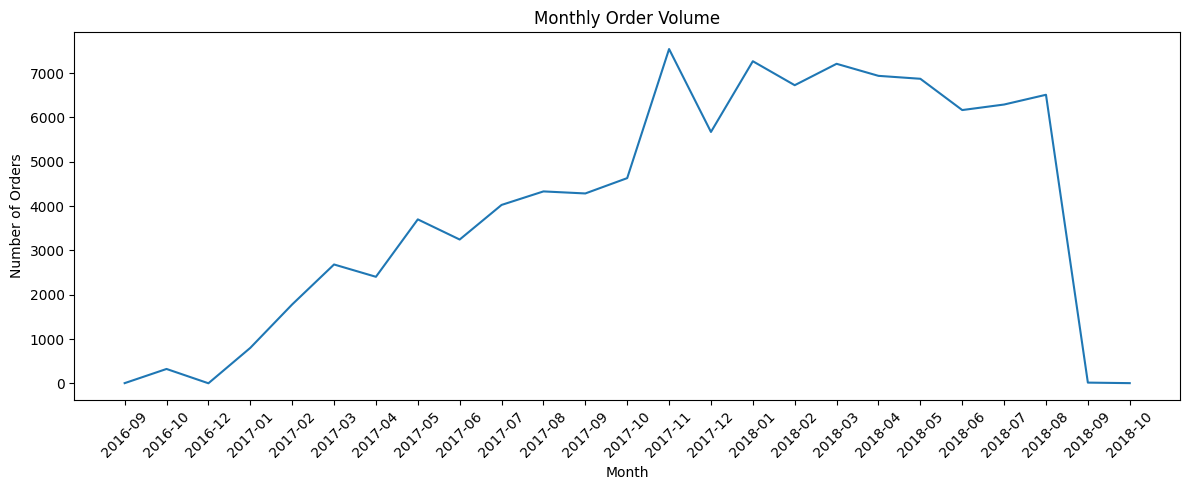

In [60]:
# Plot monthly order volume

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_analysis["purchase_month"],
    monthly_analysis["order_count"]
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly Product Revenue

Monthly product revenue is visualized to examine changes in transaction value over time.

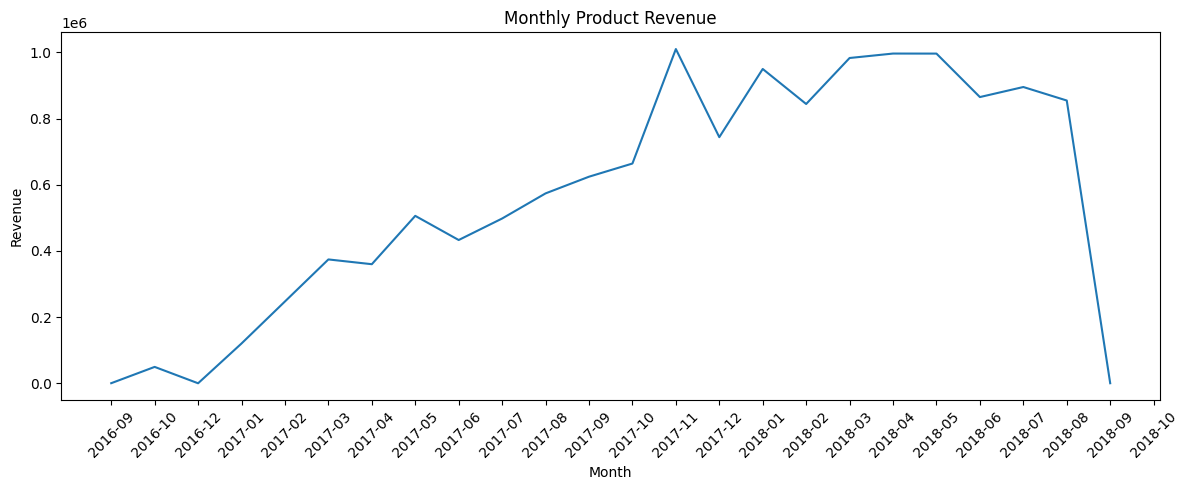

In [61]:
# Plot monthly product revenue

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_analysis["purchase_month"],
    monthly_analysis["revenue"]
)

plt.title("Monthly Product Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
# Calculate delivery time in days

delivery_data = orders[
    orders["order_delivered_customer_date"].notna()
].copy()

delivery_data["delivery_days"] = (
    delivery_data["order_delivered_customer_date"]
    - delivery_data["order_purchase_timestamp"]
).dt.days

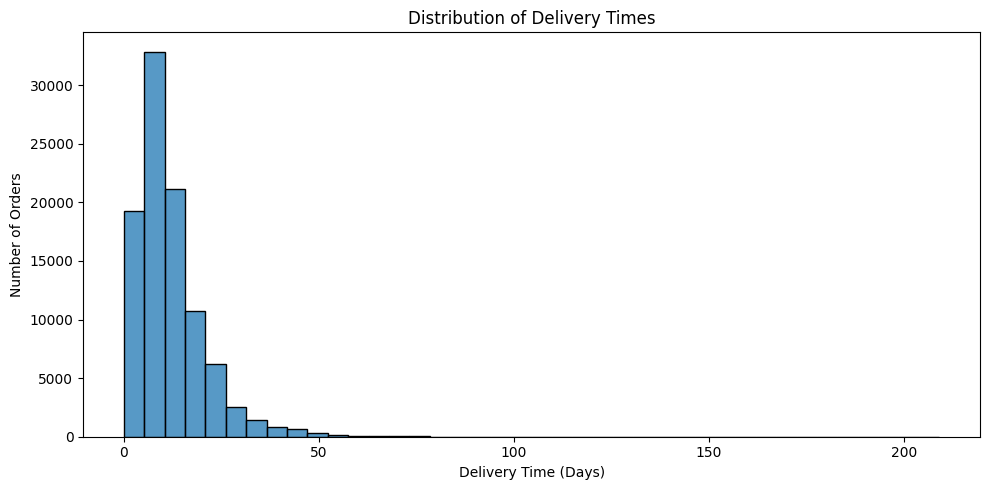

In [63]:
# Plot the distribution of delivery times

plt.figure(figsize=(10, 5))

sns.histplot(
    delivery_data["delivery_days"],
    bins=40
)

plt.title("Distribution of Delivery Times")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

## 17. Review Scores and Delivery Performance

This analysis examines whether customer review scores differ based on delivery performance.

Orders are classified as Early, On Time, or Late by comparing the actual delivery date with the estimated delivery date.

This shows an association between delivery performance and review scores; it does not establish causation.

In [64]:
# Merge reviews with delivery dates
review_delivery = reviews.merge(
    orders[[
        "order_id",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]],
    on="order_id"
)

In [65]:
# Remove missing delivery dates
review_delivery = review_delivery.dropna(
    subset=["order_delivered_customer_date", "order_estimated_delivery_date"]
)

In [66]:
# Classify delivery performance
review_delivery["delivery_status"] = np.where(
    review_delivery["order_delivered_customer_date"] <= review_delivery["order_estimated_delivery_date"],
    "On Time",
    "Late"
)

In [67]:
# Average review score by delivery status
delivery_review_summary = (
    review_delivery.groupby("delivery_status")["review_score"]
    .mean()
    .round(2)
    .reset_index()
)

delivery_review_summary

,delivery_status,review_score
0,Late,2.57
1,On Time,4.29


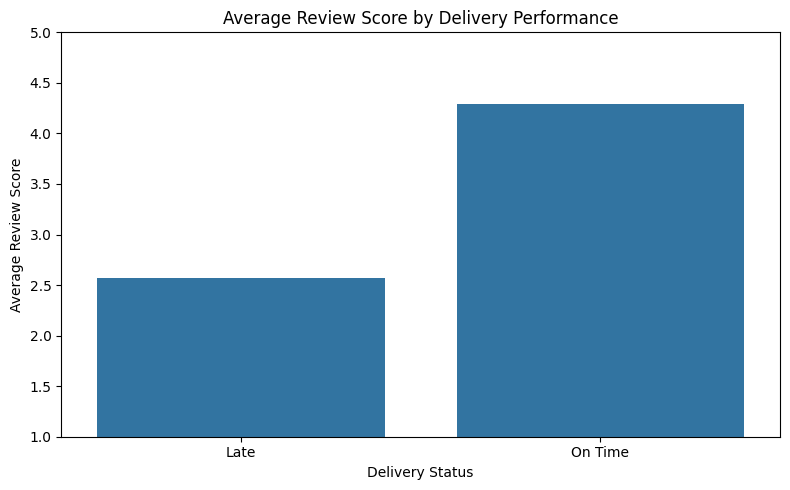

In [68]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=delivery_review_summary,
    x="delivery_status",
    y="review_score"
)

plt.title("Average Review Score by Delivery Performance")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.ylim(1, 5)
plt.tight_layout()
plt.show()

### Customer Review Scores

Customer review scores provide an indication of customer satisfaction.

This analysis examines how review scores are distributed across the orders.

In [69]:
# Count each review score

review_scores = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
)

review_scores

,count
review_score,
1,11424
2,3151
3,8179
4,19142
5,57328


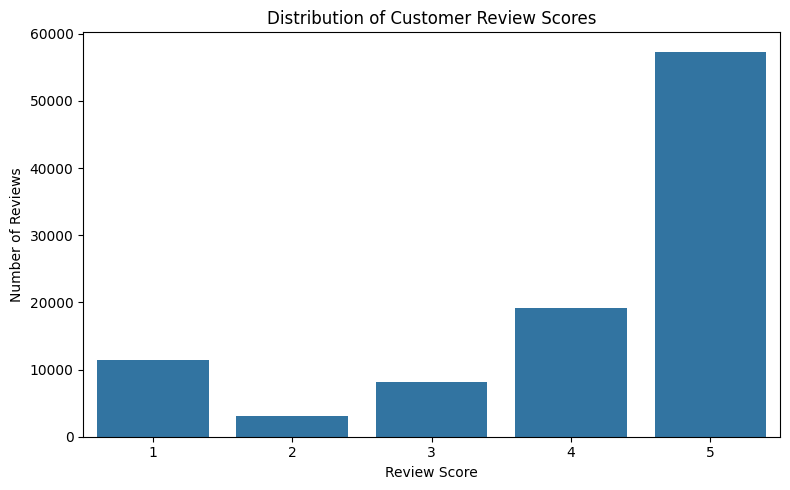

In [70]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=review_scores.index,
    y=review_scores.values
)

plt.title("Distribution of Customer Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

## 18. Product Category Performance

Product categories can be compared by the revenue they generate to identify the strongest revenue-generating categories.

In [71]:
# Calculate revenue by product category

category_revenue = (
    order_items.merge(
        products[["product_id", "product_category_name"]],
        on="product_id"
    )
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

category_revenue

,product_category_name,price
0,beleza_saude,1258681.34
1,relogios_presentes,1205005.68
2,cama_mesa_banho,1036988.68
3,esporte_lazer,988048.97
4,informatica_acessorios,911954.32
5,moveis_decoracao,729762.49
6,cool_stuff,635290.85
7,utilidades_domesticas,632248.66
8,automotivo,592720.11
9,ferramentas_jardim,485256.46


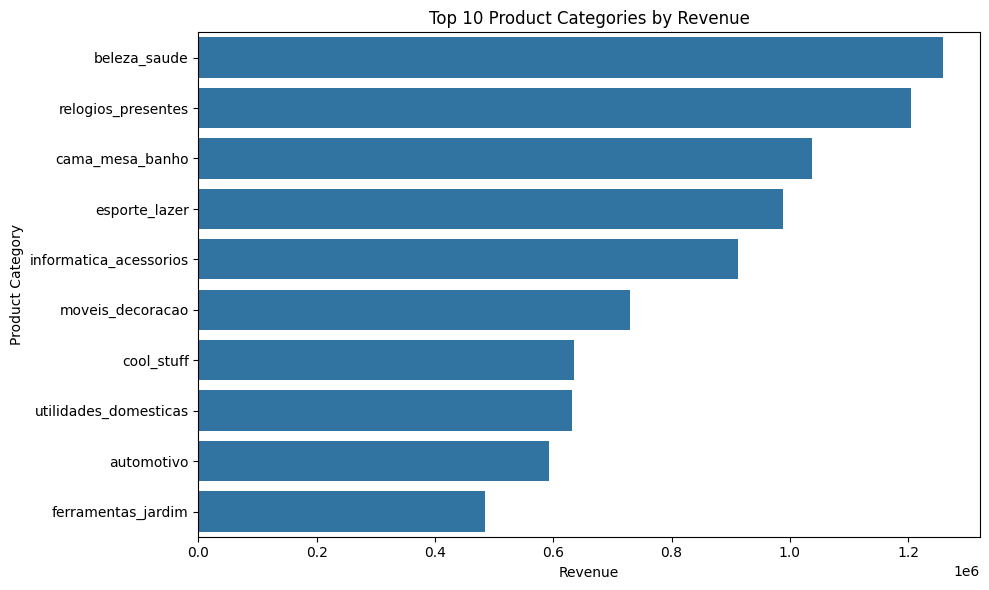

In [72]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_revenue,
    y="product_category_name",
    x="price"
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

## 19. Orders by Customer State

Examining order volume by customer state helps identify the regions generating the highest number of orders.

In [73]:
# Count orders by customer state

state_orders = (
    customers["customer_state"]
    .value_counts()
    .head(10)
    .reset_index()
)

state_orders.columns = ["state", "orders"]

state_orders

,state,orders
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


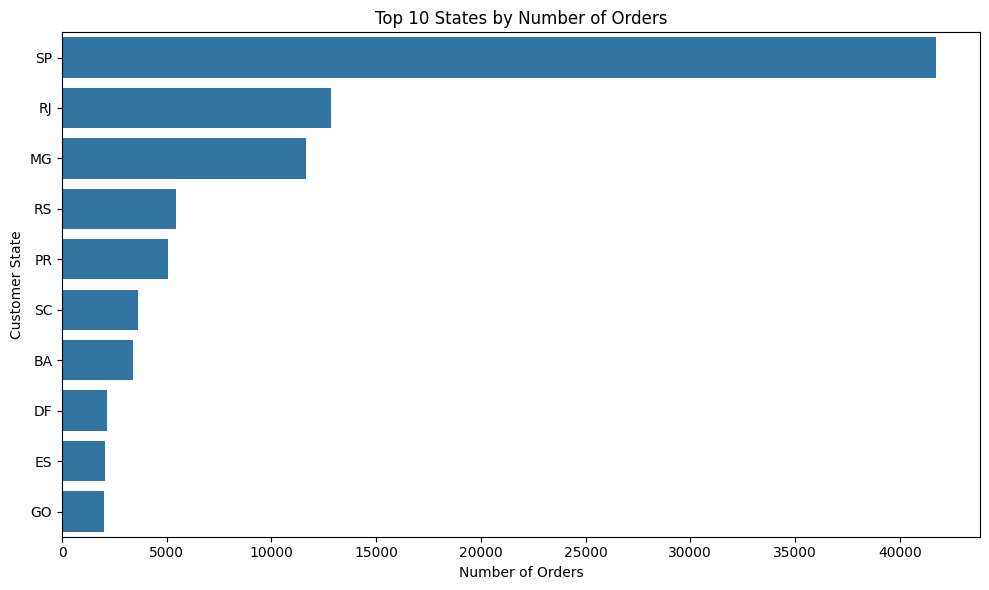

In [74]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=state_orders,
    y="state",
    x="orders"
)

plt.title("Top 10 States by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Customer State")
plt.tight_layout()
plt.show()

## 20. Product Price and Freight Cost

This analysis examines the relationship between product price and freight cost.

A scatter plot is used to identify whether higher-priced products tend to have higher shipping costs.

In [75]:
# Compare product price with freight cost

price_freight = order_items[["price", "freight_value"]].dropna()

price_freight.head()

,price,freight_value
0,58.90,13.29
1,239.90,19.93
2,199.00,17.87
3,12.99,12.79
4,199.90,18.14


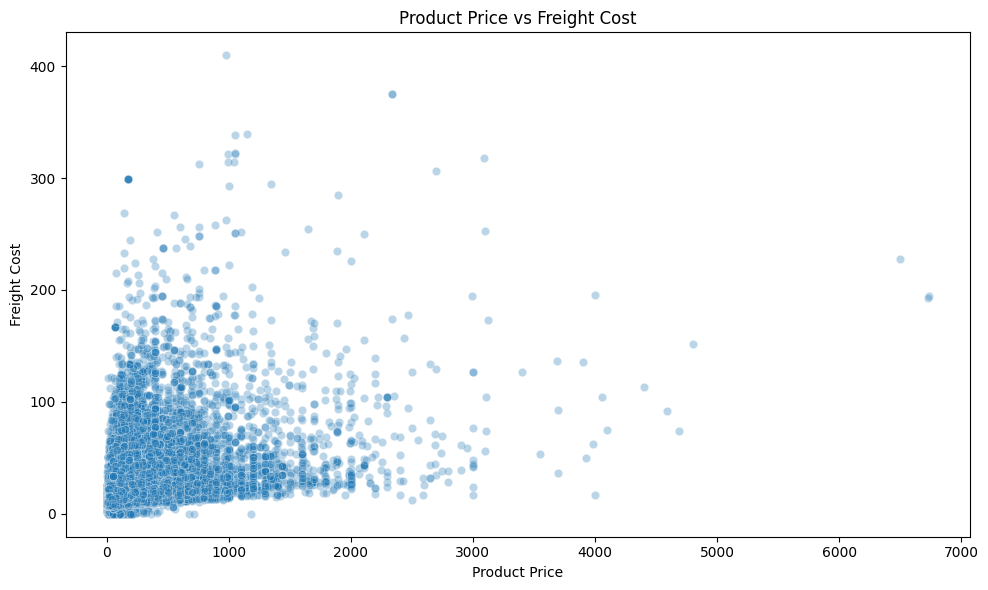

In [76]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=price_freight,
    x="price",
    y="freight_value",
    alpha=0.3
)

plt.title("Product Price vs Freight Cost")
plt.xlabel("Product Price")
plt.ylabel("Freight Cost")
plt.tight_layout()
plt.show()

## 21. Key Python Findings

The Python analysis highlighted several patterns in the Olist marketplace data:

- Order volume and revenue varied across months, showing clear changes in marketplace activity over time.
- Delivery times were concentrated within a relatively common range, with some orders taking considerably longer to arrive.
- Customer review scores showed an uneven distribution, with some ratings occurring much more frequently than others.
- A small number of product categories generated substantially more revenue than the rest.
- Order activity was concentrated in a few customer states, indicating strong geographic differences in marketplace demand.
- Product price and freight cost showed a positive relationship, although the relationship was not perfectly linear.

Overall, the Python analysis provided visual context for the patterns identified during the SQL analysis and highlighted areas for further business investigation.